# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- Rolling IQR anomaly detection
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: OpenBB
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\OpenBB.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\OpenBB.sqlite
Closed event type id: 65


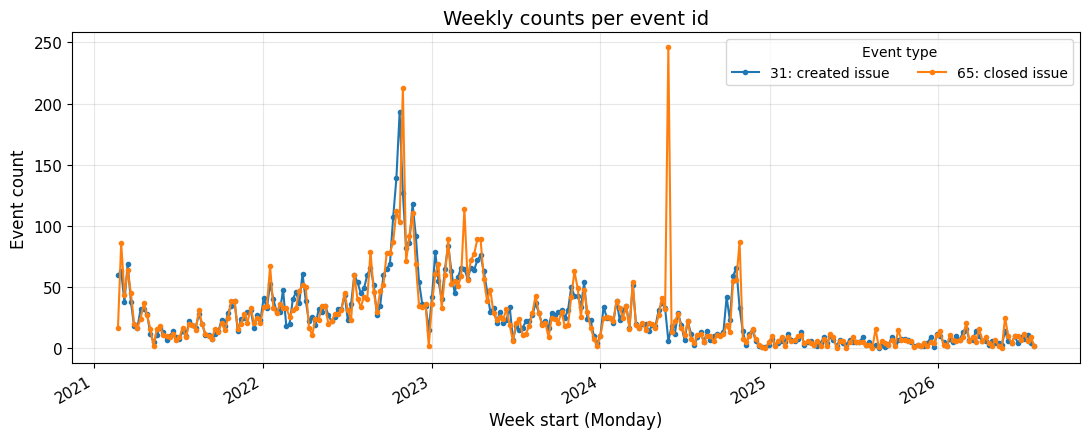

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\weekly_open_closed_summary.csv


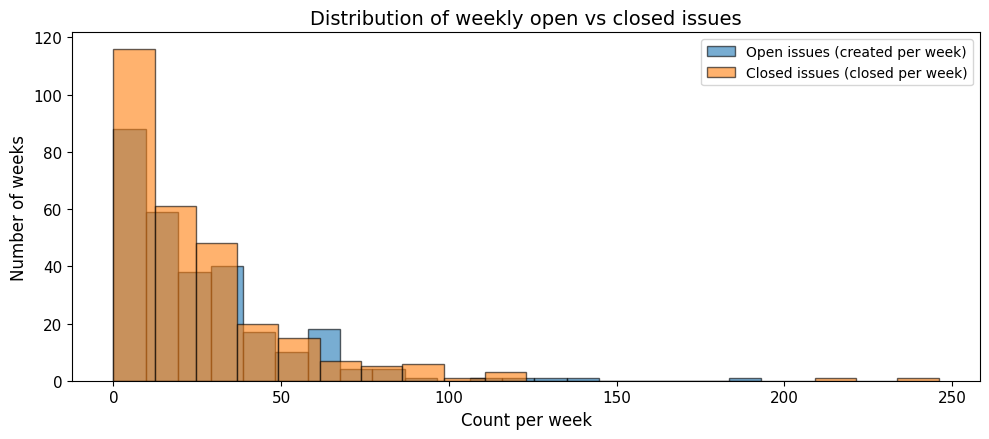

,Open issues (weekly created),Closed issues (weekly closed)
count,284.00,284.00
mean,25.48,25.86
std,25.15,28.66
min,0.00,0.00
25%,7.00,8.00
50%,18.00,18.00
75%,34.25,33.00
max,193.00,246.00


In [2]:
import sys
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "functions").exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("OpenBB")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR for detecting the anomalies 


In [3]:
from functions.anomaly import rolling_iqr_detect
from functions.config import IQR_CONFIG

rolling_iqr_anomalies = rolling_iqr_detect(
    weekly[cfg.closed_event_type_id],
    **IQR_CONFIG,
)
rolling_iqr_anomalies.to_csv(cfg.tables_dir / "rolling_iqr_anomalies.csv", index=False)
print(
    f"Detected {int(rolling_iqr_anomalies['is_anomaly'].sum())} "
    f"rolling-IQR anomalies for event_type_id={cfg.closed_event_type_id}."
)
rolling_iqr_anomalies.head()


Detected 25 rolling-IQR anomalies for event_type_id=65.


,week_start,value,rolling_q1,rolling_q3,iqr,lower_bound,upper_bound,is_anomaly,anomaly_direction,anomaly_score
0,2021-02-22,17,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
1,2021-03-01,86,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
2,2021-03-08,44,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
3,2021-03-15,64,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
4,2021-03-22,45,NaN,NaN,NaN,NaN,NaN,False,normal,0.0


## 3. Export anomaly object / event IDs


In [4]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(
    rolling_iqr_anomalies, eventsPerobj_df, cfg
)
anomaly_object_ids.head()



,week_start,object_id
0,2026-05-25,6548
1,2026-05-25,8514
2,2026-05-25,11792
3,2026-03-30,11867
4,2026-03-02,17581


## 4. Anomaly plots


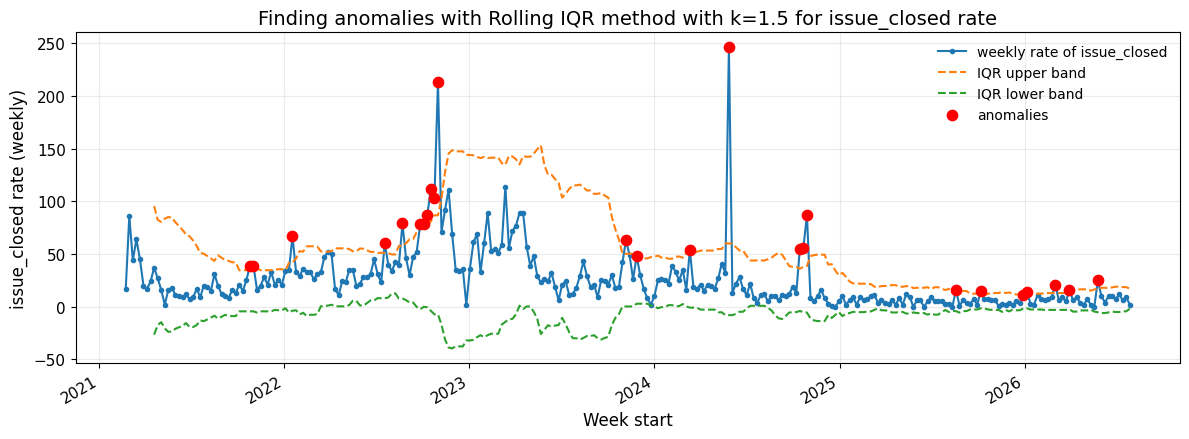

C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


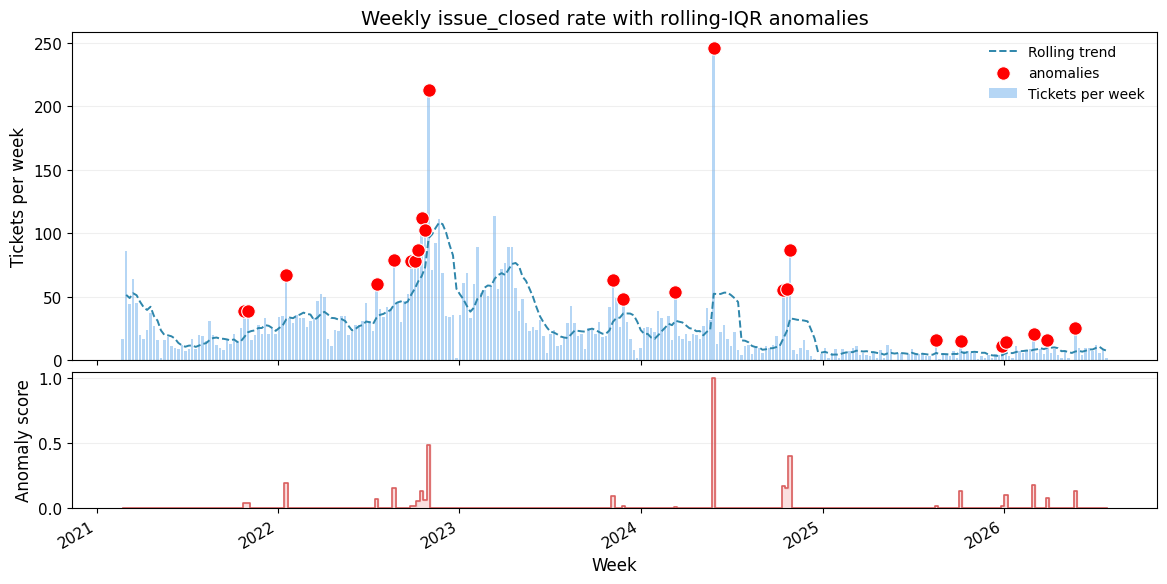

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/OpenBB')

In [5]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(rolling_iqr_anomalies, cfg)


## 5. Commit context and type classification

Link commits to issues that closed in anomaly weeks via the same `event_id` join as 8b. Classify those messages for the weekly stacked plot, and save overlapping `anomaly_issue_commit_categories`.


commit_context summary: 25 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\commit_context.csv

=== Anomaly issue commit categories (overlapping, event_id link) ===
Anomaly issues: 1664
Issues with classified commits: 879
Issues with no classified commit (assigned to other): 785
Issues in more than one category: 60
  feature_work  23
  bug_fixes     54
  tech_debt     13
  docs          8
  other         1643
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\OpenBB\anomaly_issue_commit_categories.csv
commit_typeclass_per_week summary: 25 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.010
  bug_fixes     0.021
  tech_debt     0.005
  docs          0.003
  other         0.960

Mean category ratios by anomaly_direction:
  [high] featu

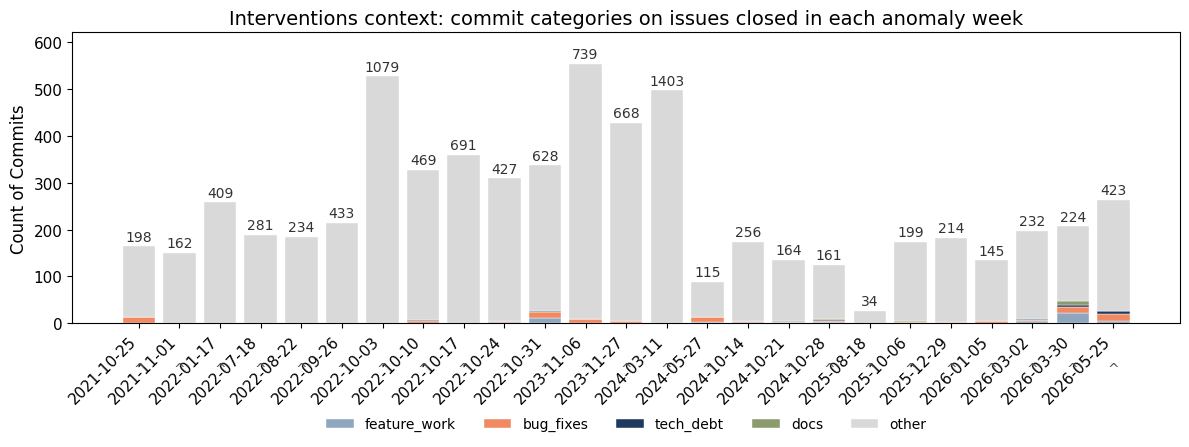

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/OpenBB')

In [6]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join, anomaly_issue_commit_categories = build_commit_context(
    rolling_iqr_anomalies, eventsPerobj_df, objects_attributes, cfg, anomaly_object_ids
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log: viewpoint of issues


In [10]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 162662 events, 7236 cases
  case:concept:name      concept:name            time:timestamp
0             10036           created 2026-04-02 09:54:20+00:00
1             10036         commented 2026-04-04 16:57:51+00:00
2             10036            closed 2026-04-04 16:57:52+00:00
3             10036  cross_referenced 2026-04-18 00:01:51+00:00
4             10036  cross_referenced 2026-05-03 15:59:30+00:00
5             10063         committed 2026-04-02 04:33:44+00:00
6             10063           created 2026-04-02 04:45:46+00:00
7             10063           labeled 2026-04-02 04:45:47+00:00
8             10063           labeled 2026-04-02 04:45:47+00:00
9             10063           labeled 2026-04-02 04:45:48+00:00


## 8a. Category-log preprocess 

Clean the raw step-6 `flat` log for commit-category discovery: keep cases that contain `closed` or `head_ref_deleted` anywhere (full traces), then drop traces with any activity repeating more than `CATEGORY_MAX_REP` times. Independent of step 8 (`MAX_REP=5`).


In [11]:
from functions.preprocessing import preprocess_flat_log

CATEGORY_MAX_REP = 10
flat_df_category_clean = preprocess_flat_log(flat, cfg, max_rep=CATEGORY_MAX_REP) 


=== Category-log preprocess (end=closed/head_ref_deleted, max_rep=10) ===
Raw: 7236 cases | 162662 events
After incomplete-end filter: 5164 cases | 98699 events
After max_rep=10: 4262 cases | 47174 events


In [ ]:
from functions.discovery import select_miners

# Available: alpha_classic, inductive_IM, heuristics_dep_0.5/0.6/0.7,
# inductive_IMf_noise_0.2/0.3/0.4, split_miner_eps_*_eta_*
# None runs all miners.
DISCOVERY_MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]


## 8b. Commit-category event logs (8a cleaned flat) and discovery in each action category

Classify every commit message and put each case from `flat_df_category_clean` into exactly one category log: if all of its commits share a category it stays there; if they span several categories (or it has no classified commit) it goes to `other`. Logs are disjoint. Then run discovery F1 on those five logs plus that cleaned whole log. Discovery methods come from `DISCOVERY_MINERS` in the cell after 8a (`None` runs all).


In [ ]:
from functions.commits import build_whole_commit_category_logs
from functions.discovery import evaluate_clean_logs, select_miners

category_logs, issue_commit_categories, commit_classified_all = build_whole_commit_category_logs(
    flat_df_category_clean, eventsPerobj_df, objects_attributes, cfg
)

commit_category_log_groups_df = {**category_logs, "whole": flat_df_category_clean}

consolidated_results_table_commit_categories, commit_category_log_groups_eventlog, _ = evaluate_clean_logs(
    commit_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_commit_categories.csv"
)
consolidated_results_table_commit_categories.head()


## 8c. Anomaly vs normal logs from cleaned flat, then discovery F1

Split `flat_df_category_clean` by anomaly object IDs from step 3: keep matching cases as the anomaly log and the rest as the normal log. Then run discovery F1 on anomaly, normal, and the cleaned whole log using `DISCOVERY_MINERS`.


In [ ]:
from functions.ocel_flatten import split_flat_by_anomaly_object_ids
from functions.discovery import evaluate_clean_logs, select_miners

anomaly_log_df, normal_log_df = split_flat_by_anomaly_object_ids(
    flat_df_category_clean, anomaly_object_ids
)

anomaly_normal_log_groups_df = {
    "anomaly": anomaly_log_df,
    "normal": normal_log_df,
    "whole": flat_df_category_clean,
}

consolidated_results_table_anomaly_normal, _, _ = evaluate_clean_logs(
    anomaly_normal_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_normal.csv",
)
consolidated_results_table_anomaly_normal


## 8d. Anomaly x commit-category logs, then discovery F1

Cross `anomaly_log_df` / `normal_log_df` from 8c with disjoint `category_logs` from 8b: each case belongs to exactly one category, then those logs are split into anomaly vs normal. Then run discovery F1 on the ten combined groups plus the cleaned whole log using `DISCOVERY_MINERS`.


In [ ]:
from functions.discovery import evaluate_clean_logs, select_miners

anomaly_ids = set(anomaly_log_df["case:concept:name"].astype(str))
normal_ids = set(normal_log_df["case:concept:name"].astype(str))

anomaly_category_log_groups_df = {
    **{f"anomaly_{name}": df[df["case:concept:name"].astype(str).isin(anomaly_ids)].copy()
       for name, df in category_logs.items()},
    **{f"normal_{name}": df[df["case:concept:name"].astype(str).isin(normal_ids)].copy()
       for name, df in category_logs.items()},
    "whole": flat_df_category_clean,
}

consolidated_results_table_anomaly_categories, _, _ = evaluate_clean_logs(
    anomaly_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_categories.csv",
)
consolidated_results_table_anomaly_categories


In [ ]:
xlsx_path = cfg.tables_dir / "consolidated_results_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    consolidated_results_table_commit_categories.to_excel(
        writer, sheet_name="commit_categories", index=False
    )
    consolidated_results_table_anomaly_normal.to_excel(
        writer, sheet_name="anomaly_normal", index=False
    )
    consolidated_results_table_anomaly_categories.to_excel(
        writer, sheet_name="anomaly_categories", index=False
    )
print(f"Saved {xlsx_path}")


## 15. Petri nets by commit category: events related to each commit category


the question:
    what process is discovered for each disjoint commit category in the preprocessed whole log?
the input:
    category_logs from step 8b (disjoint category subsets of flat_df_category_clean)
the output:
    petri net per category log (inductive_IMf_noise_0.3)


In [ ]:
#graphviz path 
import os
from pathlib import Path
import shutil

GRAPHVIZ_BIN = Path(r"C:\Program Files\Graphviz\bin")  # change if yours is elsewhere

if not (GRAPHVIZ_BIN / "dot.exe").exists():
    raise FileNotFoundError(
        f"dot.exe not found in {GRAPHVIZ_BIN}. "
        "Install Graphviz and set GRAPHVIZ_BIN to its bin folder."
    )

os.environ["PATH"] = str(GRAPHVIZ_BIN) + os.pathsep + os.environ.get("PATH", "")
print("dot found at:", shutil.which("dot"))

In [ ]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.3"])

for name, df in category_logs.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.3"](elog)
    pm4py.view_petri_net(net, im, fm)


## 16. Petri nets by anomaly, normal, and whole

the question:
    what process is discovered for anomaly vs normal vs the whole cleaned log?
the input:
    anomaly_normal_log_groups_df from step 8c
the output:
    petri net per log (inductive_IMf_noise_0.3)

In [ ]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.3"])

for name, df in anomaly_normal_log_groups_df.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.3"](elog)
    pm4py.view_petri_net(net, im, fm)
